In [1]:
from rembg import remove
from PIL import Image
from matplotlib import pyplot as plt

(-0.5, 5711.5, 4283.5, -0.5)

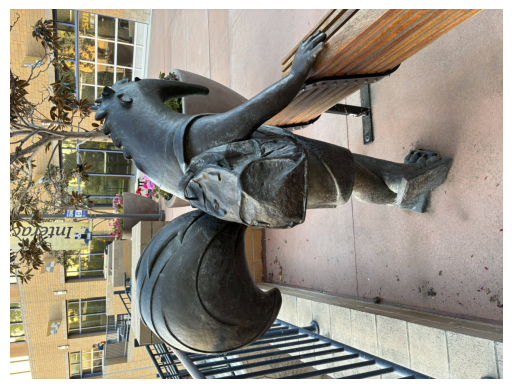

In [2]:
# img = Image.open("eval_data/chair/gt_obs/frame_000000.jpg")
img = Image.open("IMG_9741.jpg")

plt.imshow(img)
plt.axis("off")

In [3]:
segmented = remove(img)
background = Image.new("RGBA", segmented.size, (0, 0, 0, 255))
background.paste(segmented, mask=segmented.split()[3])
segmented = background
segmented.save("segmented.png")


(-0.5, 1079.5, 1919.5, -0.5)

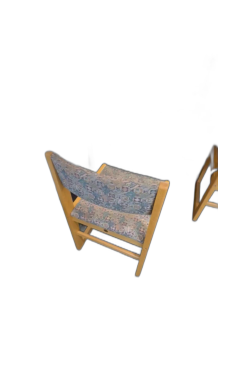

In [ ]:
plt.imshow(segmented)
plt.axis("off")

In [ ]:
from pathlib import Path

EVAL_DIR = Path("eval_data")

for obj_dir in sorted(EVAL_DIR.iterdir()):
    if not obj_dir.is_dir():
        continue
    gt_obs_dir = obj_dir / "gt_obs"
    if not gt_obs_dir.exists():
        continue

    out_dir = obj_dir / "gt_obs_segmented"
    out_dir.mkdir(exist_ok=True)

    images = sorted(gt_obs_dir.glob("*.jpg")) + sorted(gt_obs_dir.glob("*.png"))

    for idx, img_path in enumerate(images):
        img = Image.open(img_path)
        segmented = remove(img)  # RGBA with transparent background
        background = Image.new("RGBA", segmented.size, (0, 0, 0, 255))
        background.paste(segmented, mask=segmented.split()[3])
        out_path = out_dir / f"frame_{idx:06d}.png"
        background.save(out_path)
        print(f"[{obj_dir.name}] {img_path.name} -> {out_path.name}")

print("Done.")
